In [2]:
"""
Two-column AMOC with tracer: buoyancy-driven overturning in a basin connected to a Southern Ocean channel,
plus a passive tracer that advects, diffuses, convects, and exchanges horizontally between columns.

Tracer is injected at the northern surface after spin-up and propagated for 500 years. 
"""
from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

In [12]:
bs = 0.03
bs_north = 0.004
bmin = 0.0

# S.O. surface boundary conditions and grid
l = 2.e6
y = np.asarray(np.linspace(0, l, 80))
tau = 0.13
bs_SO = (bs - bmin) * (y / y[-1])**2 + bmin

A_basin = 6e13          # area of the basin
A_north = A_basin / 50. # area of northern sinking region


dt = 86400 * 30    # 30-day time step
MOC_up_iters = int(np.floor(2. * 360 * 86400 / dt))       # update overturning every ~2 months
plot_iters = int(np.ceil(300 * 360 * 86400 / dt))         # quick-look plot frequency (~300 days)
spin_years = 3500
post_years = 5 # tracer propagation after injection
total_iters = int(np.ceil((spin_years + post_years) * 360 * 86400 / dt))
injection_iter = int(np.ceil(spin_years * 360 * 86400 / dt))
kappa = 3e-5       # diapycnal diffusivity (m^2/s)

In [13]:
z = np.asarray(np.linspace(-4000, 0, 80))


def b_basin(z):
    return bs * np.exp(z / 300.)

def b_north(z):
    return bs_north * np.exp(z / 300.)

In [14]:
basin = Column(z=z, kappa=kappa, Area=A_basin, b=b_basin, bs=bs, bbot=bmin)
north = Column(z=z, kappa=kappa, Area=A_north, b=b_north, bs=bs_north, bbot=bmin)

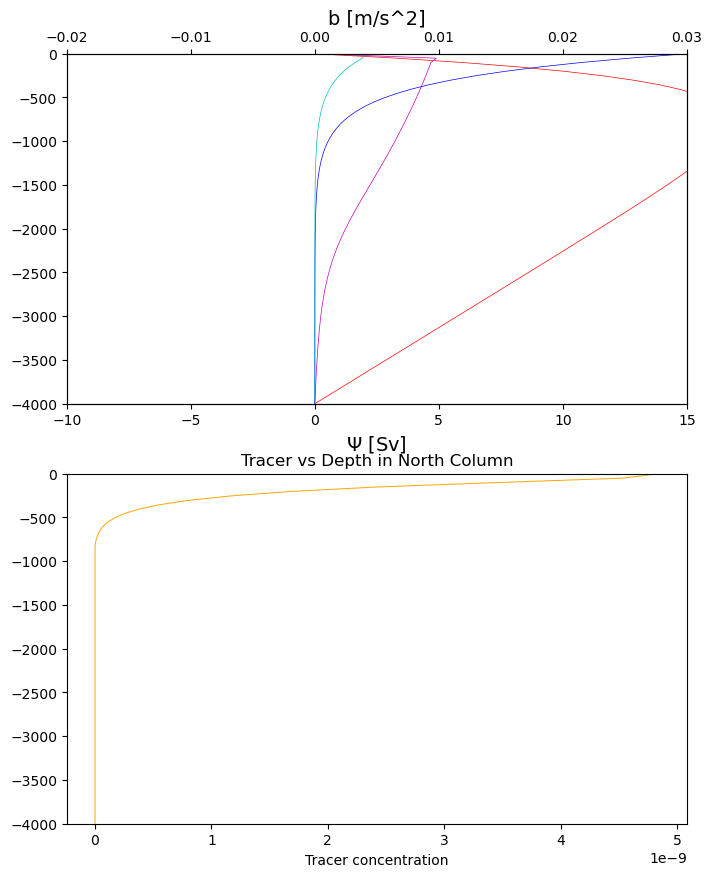

<Figure size 640x480 with 0 Axes>

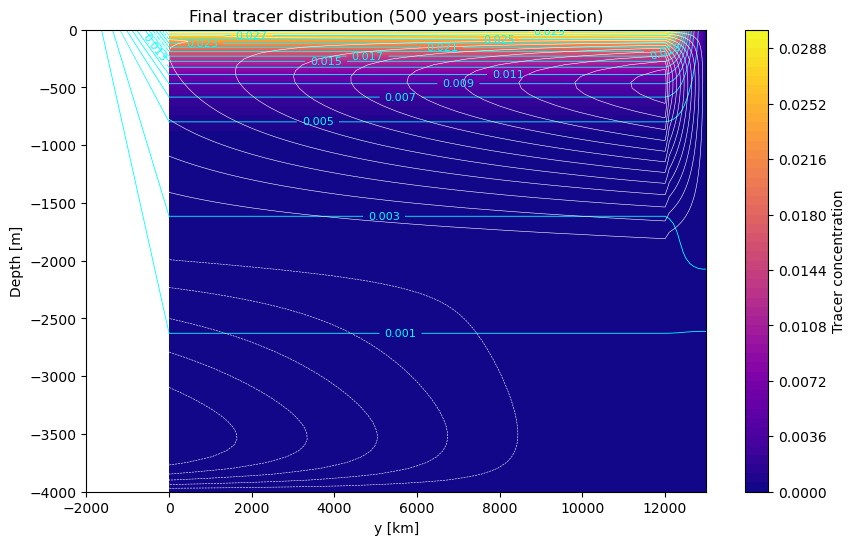

Basin tracer inventory: 5.307e+14
North tracer inventory: 5.127e+11
Total tracer inventory: 5.312e+14


In [15]:
# Initialize tracer (zero initially)
basin.add_tracer(0.0)
north.add_tracer(0.0)



AMOC = Psi_Thermwind(z=z, b1=b_basin, b2=b_north, f=1e-4, t1=basin.tracer, t2=north.tracer)
AMOC.solve()
Psi_iso_b, Psi_iso_n = AMOC.Psibz()

SO = Psi_SO(
    z=z, y=y, b=b_basin(z), bs=bs_SO, tau=tau, f=1e-4,
    L=5e6, KGM=1000., c=0.1, bvp_with_Ek=True
)
SO.solve()

t_basin_iso, t_north_iso = AMOC.Psitz()#t1=basin.tracer, t2=north.tracer)



fig = plt.figure(figsize=(8, 10))
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)
ax1b = ax1.twiny()
ax1.set_ylim((-4e3, 0))
ax1.set_xlim((-10, 15))
ax1b.set_xlim((-0.02, 0.03))
ax1.set_xlabel('$\\Psi$ [Sv]', fontsize=14)
ax1b.set_xlabel('b [m/s^2]', fontsize=14)
ax2.set_ylim((-4e3, 0))
ax2.set_xlabel('Tracer concentration')
ax2.set_title('Tracer vs Depth in North Column')

dz = np.diff(z)[0]
dy_SO = y[1] - y[0]
dy_N = 1e3


for ii in range(total_iters):

    wAb = (Psi_iso_b - SO.Psi) * 1e6
    wAN = -Psi_iso_n * 1e6

    v_SO = -np.gradient(SO.Psi, dz)
    vdx_SO_to_basin = v_SO * SO.L

    v_AMOC = -np.gradient(AMOC.Psi, dz)
    vdx_basin_to_north = v_AMOC
    vdx_north_to_basin = -v_AMOC

    b_in_from_SO = bs_SO
    b_in_from_basin = basin.b.copy()
    b_in_from_north = north.b.copy()

    basin.timestep(wA=wAb, dt=dt)
    north.timestep(wA=wAN, dt=dt, do_conv=True)

    north.horadv_tracer(vdx_in=vdx_basin_to_north, tracer_in=b_in_from_basin, dt=dt)
    north.horadv_tracer(vdx_in=-vdx_north_to_basin, tracer_in=b_in_from_north, dt=dt)

    basin.horadv_tracer(vdx_in=vdx_SO_to_basin, tracer_in=b_in_from_SO, dt=dt)
    basin.horadv_tracer(vdx_in=vdx_north_to_basin, tracer_in=b_in_from_north, dt=dt)
    north.vertadvdiff_tracer(wA=wAN, dt= dt)
    if ii == injection_iter:
        north.add_tracer(amount=1, depth_range=None, as_concentration=False)


    if ii % MOC_up_iters == 0:
        AMOC.update(b1=basin.b, b2=north.b)
        AMOC.solve()
        Psi_iso_b, Psi_iso_n = AMOC.Psibz()
        SO.update(b=basin.b)
        SO.solve()
        t_basin_iso, t_north_iso = AMOC.Psitz()

    if ii % plot_iters == 0 or ii == injection_iter or ii == total_iters - 1:
        ax1.plot(AMOC.Psi, AMOC.z, linewidth=0.5, color='r')
        ax1.plot(SO.Psi, SO.z, linewidth=0.5, color='m')
        ax1b.plot(basin.b, basin.z, linewidth=0.5, color='b')
        ax1b.plot(north.b, north.z, linewidth=0.5, color='c')
        ax2.plot(north.tracer, north.z, linewidth=0.7, color='orange')
        plt.pause(0.01)



ax1.plot(AMOC.Psi, AMOC.z, linewidth=2, color='r')
ax1.plot(SO.Psi, SO.z, linewidth=2, color='m')
ax1.plot(SO.Psi_Ek, SO.z, linewidth=1, color='m', linestyle='--')
ax1.plot(SO.Psi_GM, SO.z, linewidth=1, color='m', linestyle=':')
ax1b.plot(basin.b, basin.z, linewidth=2, color='b')
ax1b.plot(north.b, north.z, linewidth=2, color='c')
ax1.plot(0. * AMOC.z, AMOC.z, linewidth=0.5, color='k')
ax2.plot(north.tracer, north.z, linewidth=2, color='orange')
plt.tight_layout()
plt.show()


# bint = Interpolate_channel(y=y, z=z, bs=bs_SO, bn=basin.b)

bint = Interpolate_channel(y=y, z=z, bs=bs_SO, bn=basin.b)

# t_basin_iso, t_north_iso = AMOC.Psitz(tracer1=basin.tracer, tracer2 = north.tracer)


bint.set_tracer(ts=lambda yy: t_basin_iso[np.argmin(np.abs(AMOC.bgrid - bs_SO[np.argmin(np.abs(y - yy))]))],
                tn=lambda zz: basin.tracer[np.argmin(np.abs(z - zz))])
bsouth = bint.gridit()

tracer_channel = bint.tracer_grid()  # shape (len(y), len(z))


ybasin = np.linspace(200., 12000., 60)
bbasin = np.tile(basin.b, (len(ybasin), 1))

ynorth = np.linspace(12100., 13000., 10)
bnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
    bnorth[:, iz] = interp1d(
        [11900., 12000., 12900., 13000.],
        [basin.b[iz], basin.b[iz], north.b[iz], north.b[iz]],
        kind='quadratic'
    )(ynorth)

ynew = np.concatenate(((y - l) / 1e3, ybasin, ynorth))
bnew = np.concatenate((bsouth, bbasin, bnorth))

psiarray_iso = np.zeros((len(ynew), len(z)))
psiarray_z = np.zeros((len(ynew), len(z)))

for iy in range(1, len(y)):
    psiarray_iso[iy, :] = np.interp(bnew[iy, :], basin.b, SO.Psi)
    psiarray_z[iy, :] = psiarray_iso[iy, :]
for iy in range(len(y), len(y) + len(ybasin)):
    psiarray_iso[iy, :] = (ynew[iy] * AMOC.Psibz()[0] + (10000. - ynew[iy]) * SO.Psi) / 10000.
    psiarray_z[iy, :] = (ynew[iy] * AMOC.Psi + (10000. - ynew[iy]) * SO.Psi) / 10000.
for iy in range(len(y) + len(ybasin), len(ynew)):
    psiarray_iso[iy, :] = np.interp(bnew[iy, :], AMOC.bgrid, AMOC.Psib())
    psiarray_z[iy, :] = ((13000. - ynew[iy]) * AMOC.Psi) / 1000.
psiarray_iso[-1, :] = 0.

blevs = np.arange(0.001, 0.03, 0.002)
plevs = np.concatenate((np.arange(-15., -0.4, 0.5), np.arange(1., 16., 1.)))

# # Isopycnal overturning (diagnostic)
# fig = plt.figure(figsize=(10, 5))
# ax1f = fig.add_subplot(111)
# CS = ax1f.contour(ynew, z, bnew.transpose(), levels=blevs, colors='k', linewidths=1.0, linestyles='solid')
# ax1f.clabel(CS, fontsize=10)
# ax1f.contour(ynew, z, psiarray_iso.transpose(), levels=plevs, colors='k', linewidths=0.5)
# CS = ax1f.contourf(ynew, z, psiarray_iso.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-15, vmax=15)
# ax1f.set_xlabel('y [km]')
# ax1f.set_ylabel('Depth [m]')
# ax1f.set_title('Isopycnal Overturning')
# plt.show()

# # Depth-averaged overturning (diagnostic)
# fig = plt.figure(figsize=(10, 5))
# ax2f = fig.add_subplot(111)
# CS = ax2f.contour(ynew, z, bnew.transpose(), levels=blevs, colors='k', linewidths=1.0, linestyles='solid')
# ax2f.clabel(CS, fontsize=10)
# ax2f.contour(ynew, z, psiarray_z.transpose(), levels=plevs, colors='k', linewidths=0.5)
# CS = ax2f.contourf(ynew, z, psiarray_z.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-15, vmax=15)
# ax2f.set_xlabel('y [km]')
# ax2f.set_ylabel('Depth [m]')
# ax2f.set_title('Depth-averaged Overturning')
# plt.show()

# -------------------------
# Build a y–z tracer field:
# - Southern channel & basin interior: use basin column tracer (fills interior southward)
# - Far north segment: smoothly transition from basin -> north tracer by y
tracer_2d = np.zeros_like(bnew)

# southern channel segment
for iy in range(len(y)):
    tracer_2d[iy, :] = tracer_channel[iy, :]

# basin interior segment
for iy in range(len(y), len(y) + len(ybasin)):
    tracer_2d[iy, :] = basin.tracer

# far north segment: linear blend in y from basin to north profiles
start = len(y) + len(ybasin)
end = len(ynew)
for iy in range(start, end):
    w = (iy - start) / max(1, (end - start - 1))
    tracer_2d[iy, :] = (1.0 - w) * basin.tracer + w * north.tracer

# numeric safety
tracer_2d = np.clip(tracer_2d, 0.0, None)

# Plot tracer colourmap over y–z
fig = plt.figure(figsize=(10, 6))
axT = fig.add_subplot(111)
Ct = axT.contourf(ynew, z, tracer_2d.transpose(), levels=50, cmap='plasma')
fig.colorbar(Ct, ax=axT, label='Tracer concentration')
CSb = axT.contour(ynew, z, bnew.transpose(), levels=blevs, colors='cyan', linewidths=0.6)
axT.clabel(CSb, fontsize=8)
axT.contour(ynew, z, psiarray_z.transpose(), levels=plevs, colors='w', linewidths=0.4)
axT.set_xlabel('y [km]')
axT.set_ylabel('Depth [m]')
axT.set_title('Final tracer distribution (500 years post-injection)')
plt.show()


basin_inventory = basin.tracer_inventory()
north_inventory = north.tracer_inventory()
print(f"Basin tracer inventory: {basin_inventory:.3e}")
print(f"North tracer inventory: {north_inventory:.3e}")
print(f"Total tracer inventory: {(basin_inventory + north_inventory):.3e}")

In [7]:
import inspect

In [40]:
print(inspect.getsource(Column))

class Column(object):
  r"""
  Vertical Advection-Diffusion Column Model

  Instances of this class represent 1D representations of buoyancy in a water
  column governed by vertical advection and diffusion. The velocity
  profile is required as an input. The script can either compute the equilibrium
  buoyancy profile for a given vertical velocity profile and boundary conditions
  or compute the tendency and perform a time-step of given length.
  BCs have to be fixed buoyancy at the top and either fixed b or db/dz at the bottom
  The time-stepping version can also handle horizontal advection
  into the column. This is, however, not (yet) implemented for the equilibrium solver

  ! Edits made 11 Nov 2025 to allow for propagation of a passive tracer !
  """
  def __init__(
      self,
      z=None,    # grid (input)
      kappa=None,    # diffusivity profile (input)
      bs=0.025,    # surface buoyancy bound. cond (input)
      bbot=0.0,    # bottom buoyancy boundary condition (input)  

In [42]:
print(inspect.getsource(Psi_Thermwind))

class Psi_Thermwind(object):
  r"""
  Thermal Wind Closure

  Instances of this class represent the overturning circulation between two columns,
  given buoyancy profiles in those columns.

  The model assumes a thermal-wind based equation for the overturning circulation
  as in Nikurashin and Vallis (2012):

  .. math::
    d_{zz}\left(\Psi\right) = f^{-1} (b_2 - b_1)

  This equation is solved subject to the boundary conditions:

  .. math::
    \Psi(0) = \Psi(-H) = 0 

  (these BCs are different than NV2012)

  An upwind isopycnal mapping is used to compute the isopycnal overturning transport.

  ! Psit and Psitz added 13 Nov !
  """
  def __init__(
      self,
      f=1.2e-4,    # Coriolis parameter (input)
      z=None,    # grid (input)
      sol_init=None,    # Initial conditions for ODE solver (input)
      b1=None,    # Buoyancy in the basin (input, output)
      b2=0.,    # Buoyancy in the deep water formation region (input, output)
      t1 = None, 
      t2 = 0.,
  ):
    r

In [43]:
print(inspect.getsource(Psi_SO))

class Psi_SO(object):
  r"""
  Southern Ocean Overturning Transport Model

  Instances of this class represent a 1D model of the overturning transport in
  the Southern Ocean interior, calculated based on a density profile in the
  adjoining basin, and local surface buoyancy and surface wind stress in the SO.

    ! Not changed for passive tracer propagation !


  """
  def __init__(
      self,
      z=None,    # vertical grid (array, in)
      y=None,    # horizontal grid (array, in)  
      b=None,    # buoyancy profile at northern end of ACC (function, array or float, in)
      bs=None,    # surface buoyancy (function, array or float, in)

      tracer = None,
      ts = None, 
      
      tau=None,    # surface wind stress (function, array or float, in)  
      f=1.2e-4,    # Coriolis parameter (in)
      rho=1030,    # Density of sea water (in)
      L=1e7,    # Zonal length of the ACC (in)
      KGM=1e3,    # GM coefficient (in)
      c=None,    # phase speed for F2010 BVP smoo

In [47]:
print(inspect.getsource(Interpolate_channel))

      y=None,    # y-grid



In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

from pymoc.modules import Column
from pymoc.modules import Psi_Thermwind
from pymoc.modules import Psi_SO
from pymoc.plotting import Interpolate_channel

from pymoc.modules.Qolumn import Qolumn as Qolumn
from pymoc.modules.Qsi_thermwind import Qsi_Thermwind as Qsi_Thermwind
from pymoc.modules.Qsi_SO import Qsi_SO as Qsi_SO

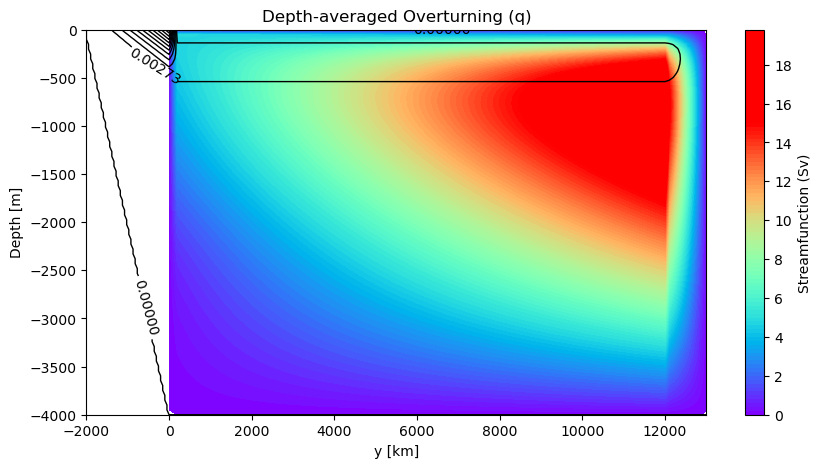

In [32]:
bs = 0.03
bs_north = 0.004
bmin = 0.0


### ??? should this be the same as buoyancy?
qs = 0.03
qs_north = 0.004
qmin = 0.0

l = 2.0e6
y = np.linspace(0, l, 40)
tau = 0.13
bs_SO = (bs - bmin) * (y / y[-1])**2 + bmin
qs_SO = (qs - qmin) * (y / y[-1])**2 + qmin
A_basin = 6e13
A_north = A_basin / 50

dt = 86400 * 30


MOC_up_iters = int(np.floor(2.0 * 360 * 86400 / dt))
plot_iters = int(np.ceil(300 * 360 * 86400 / dt))

total_iters_b = int(np.ceil(3500 * 360 * 86400 / dt))
total_iters_q = int(np.ceil(50 * 360 * 86400 / dt))

kappa = 3e-5
z = np.linspace(-4000, 0, 80)

# def q_north_surface_decay(y_array, z_array, q_max=0.03):
#     q_init = np.zeros((len(y_array), len(z_array)))
#     y_mid = y_array[len(y_array)//2]  # midpoint of y
#     for iy, yy in enumerate(y_array):
#         surface_decay = max(0, 1 - (yy / y_mid))  # decays from 1 to 0
#         q_init[iy, :] = q_max * surface_decay * np.exp(z_array / 300.0)
#     return q_init


def b_basin(z_in):
    return bs * np.exp(z_in / 300.0)

def b_north(z_in):
    return bs_north * np.exp(z_in / 300.0)

def q_basin_init(z_in):
    return qs * np.exp(z_in / 300.0)

def q_north_init(z_in):
    return qs_north * np.exp(z_in / 300.0)

AMOC_b = Psi_Thermwind(z=z, b1=b_basin, b2=b_north, f=1e-4)
AMOC_b.solve()
Psi_iso_b, Psi_iso_n = AMOC_b.Psibz()

SO_b = Psi_SO(
    z=z, y=y, b=b_basin(z), bs=bs_SO, tau=tau,
    f=1e-4, L=5e6, KGM=1000., c=0.1, bvp_with_Ek=True
)
SO_b.solve()

basin_b = Column(z=z, kappa=kappa, Area=A_basin, b=b_basin, bs=bs, bbot=bmin)
north_b = Column(z=z, kappa=kappa, Area=A_north, b=b_north, bs=bs_north, bbot=bmin)

AMOC_q = Qsi_Thermwind(z=z, q1=q_basin_init, q2=q_north_init, f=1e-4)
AMOC_q.solve()
Psi_iso_qb, Psi_iso_qn = AMOC_q.Psiqz()

SO_q = Qsi_SO(
    z=z, y=y, q=q_basin_init(z), qs=qs_SO, tau=tau,
    f=1e-4, L=5e6, KGM=1000., c=0.1, bvp_with_Ek=True
)
SO_q.solve()

basin_q = Qolumn(z=z, kappa=kappa, Area=A_basin, q=q_basin_init)
north_q = Qolumn(z=z, kappa=kappa, Area=A_north, q=q_north_init)

# fig = plt.figure(figsize=(6, 10))
# ax1 = fig.add_subplot(111)
# ax2 = ax1.twiny()
# plt.ylim((-4e3, 0))
# ax1.set_xlim((-10, 15))
# ax2.set_xlim((-0.02, 0.03))
# ax1.set_xlabel('$\\Psi$ (Sv)', fontsize=14)
# ax2.set_xlabel('b (blue) / q (orange)', fontsize=14)

surface_idx = -1

for ii in range(0, total_iters_b):

    wAb = (Psi_iso_b - SO_b.Psi) * 1e6
    wAN = -Psi_iso_n * 1e6

    basin_b.timestep(wA=wAb, dt=dt)
    north_b.timestep(wA=wAN, dt=dt, do_conv=True)

    if ii < total_iters_q:

        wAq_b = (Psi_iso_qb - SO_q.Psi) * 1e6
        wAq_n = -Psi_iso_qn * 1e6

        Area_b = basin_q.Area(basin_q.z)
        Area_n = north_q.Area(north_q.z)

        # vdx_in_profile_b = (wAq_n - wAq_b) / Area_b
        # vdx_in_profile_n = -vdx_in_profile_b

        vdx_in_profile_b = np.zeros_like(basin_q.q)
        vdx_in_profile_n = np.zeros_like(north_q.q)

        basin_q.timestep(
            wA=wAq_b,
            dt=dt,
            vdx_in=vdx_in_profile_b,
            q_in=north_q.q
        )

        north_q.timestep(
            wA=wAq_n,
            dt=dt,
            do_conv=True,
            vdx_in=vdx_in_profile_n,
            q_in=basin_q.q
        )


    # if ii % MOC_up_iters == 0:
    #     AMOC_b.update(b1=basin_b.b, b2=north_b.b)
    #     AMOC_b.solve()
    #     Psi_iso_b, Psi_iso_n = AMOC_b.Psibz()
    #     SO_b.update(b=basin_b.b)
    #     SO_b.solve()

    #     if ii < total_iters_q:
    #         AMOC_q.update(q1=basin_q.q, q2=north_q.q)
    #         AMOC_q.solve()
    #         Psi_iso_qb, Psi_iso_qn = AMOC_q.Psiqz()
    #         SO_q.update(q=basin_q.q)
    #         SO_q.solve()

    if ii % plot_iters == 0:
        ax1.plot(AMOC_b.Psi, AMOC_b.z, linewidth=0.5, color='r')
        ax1.plot(SO_b.Psi, SO_b.z, linewidth=0.5, color='m')
        ax2.plot(basin_b.b, basin_b.z, linewidth=0.5, color='b')
        ax2.plot(north_b.b, north_b.z, linewidth=0.5, color='c')

        if ii < total_iters_q:
            ax1.plot(AMOC_q.Psi, AMOC_q.z, linewidth=0.5, color='darkorange')
            ax1.plot(SO_q.Psi, SO_q.z, linewidth=0.5, color='green')
            ax2.plot(basin_q.q, basin_q.z, linewidth=0.5, color='darkorange')
            ax2.plot(north_q.q, north_q.z, linewidth=0.5, color='green')

        plt.pause(0.01)

# ax1.plot(AMOC_b.Psi, AMOC_b.z, linewidth=2, color='r', label='AMOC (b)')
# ax1.plot(SO_b.Psi, SO_b.z, linewidth=2, color='m', label='SO (b)')
# ax1.plot(SO_b.Psi_Ek, SO_b.z, linewidth=1, color='m', linestyle='--', label='Ekman (b)')
# ax1.plot(SO_b.Psi_GM, SO_b.z, linewidth=1, color='m', linestyle=':', label='GM (b)')

# ax1.plot(AMOC_q.Psi, AMOC_q.z, linewidth=2, color='darkorange', label='AMOC (q)')
# ax1.plot(SO_q.Psi, SO_q.z, linewidth=2, color='green', label='SO (q)')

# ax2.plot(basin_b.b, basin_b.z, linewidth=2, color='b')
# ax2.plot(north_b.b, north_b.z, linewidth=2, color='c')
# ax2.plot(basin_q.q, basin_q.z, linewidth=2, color='darkorange')
# ax2.plot(north_q.q, north_q.z, linewidth=2, color='green')
# ax1.plot(0.0 * AMOC_b.z, AMOC_b.z, linewidth=0.5, color='k')
# ax1.legend(loc='lower right', fontsize=8)

bint = Interpolate_channel(y=y, z=z, bs=bs_SO, bn=basin_b.b)
bsouth = bint.gridit()

ybasin = np.linspace(200., 12000., 60)
bbasin = np.tile(basin_b.b, (len(ybasin), 1))

ynorth = np.linspace(12100., 13000., 10)
bnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
    bnorth[:, iz] = interp1d(
        [11900., 12000., 12900., 13000.],
        [basin_b.b[iz], basin_b.b[iz], north_b.b[iz], north_b.b[iz]],
        kind='quadratic'
    )(ynorth)

ynew = np.concatenate(((y - l) / 1e3, ybasin, ynorth))
bnew = np.concatenate((bsouth, bbasin, bnorth))

psiarray_iso_b = np.zeros((len(ynew), len(z)))
psiarray_z_b   = np.zeros((len(ynew), len(z)))

for iy in range(1, len(y)):
    psiarray_iso_b[iy, :] = np.interp(bnew[iy, :], basin_b.b, SO_b.Psi)
    psiarray_z_b[iy, :]   = psiarray_iso_b[iy, :]
for iy in range(len(y), len(y) + len(ybasin)):
    psiarray_iso_b[iy, :] = (ynew[iy] * AMOC_b.Psibz()[0] + (10000. - ynew[iy]) * SO_b.Psi) / 10000.
    psiarray_z_b[iy, :]   = (ynew[iy] * AMOC_b.Psi + (10000. - ynew[iy]) * SO_b.Psi) / 10000.
for iy in range(len(y) + len(ybasin), len(ynew)):
    psiarray_iso_b[iy, :] = np.interp(bnew[iy, :], AMOC_b.bgrid, AMOC_b.Psib())
    psiarray_z_b[iy, :]   = ((13000. - ynew[iy]) * AMOC_b.Psi) / 1000.
psiarray_iso_b[-1, :] = 0.0

blevs = np.arange(0.001, 0.03, 0.002)
plevs = np.concatenate((np.arange(-15., -0.4, 0.5), np.arange(1., 16., 1.)))

# fig = plt.figure(figsize=(10, 5))
# ax = fig.add_subplot(111)
# CSb = ax.contour(ynew, z, bnew.T, levels=blevs, colors='k', linewidths=1.0, linestyles='solid')
# ax.clabel(CSb, fontsize=10)
# ax.contour(ynew, z, psiarray_iso_b.T, levels=plevs, colors='k', linewidths=0.5)
# CSf = ax.contourf(ynew, z, psiarray_iso_b.T, levels=plevs, cmap=plt.cm.bwr, vmin=-15, vmax=15)
# cbar = fig.colorbar(CSf, ax=ax)
# cbar.set_label('Streamfunction (Sv)')
# ax.set_xlabel('y [km]')
# ax.set_ylabel('Depth [m]')
# ax.set_title('Isopycnal Overturning (buoyancy)')

# fig = plt.figure(figsize=(10, 5))
# ax = fig.add_subplot(111)
# CSb = ax.contour(ynew, z, bnew.T, levels=blevs, colors='k', linewidths=1.0, linestyles='solid')
# ax.clabel(CSb, fontsize=10)
# ax.contour(ynew, z, psiarray_z_b.T, levels=plevs, colors='k', linewidths=0.5)
# CSf = ax.contourf(ynew, z, psiarray_z_b.T, levels=plevs, cmap=plt.cm.bwr, vmin=-15, vmax=15)
# cbar = fig.colorbar(CSf, ax=ax)
# cbar.set_label('Streamfunction (Sv)')
# ax.set_xlabel('y [km]')
# ax.set_ylabel('Depth [m]')
# ax.set_title('Depth-averaged Overturning (buoyancy)')

qint = Interpolate_channel(y=y, z=z, bs=qs_SO, bn=basin_b.b)
qsouth = qint.gridit()

ybasin = np.linspace(200., 12000., 60)
qbasin = np.tile(basin_q.q, (len(ybasin), 1))

ynorth = np.linspace(12100., 13000., 10)
qnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
    qnorth[:, iz] = interp1d(
        [11900., 12000., 12900., 13000.],
        [basin_q.q[iz], basin_q.q[iz], north_q.q[iz], north_q.q[iz]],
        kind='quadratic'
    )(ynorth)

ynew = np.concatenate(((y - l) / 1e3, ybasin, ynorth))
qnew = np.concatenate((qsouth, qbasin, qnorth))

psiarray_iso_q = np.zeros((len(ynew), len(z)))
psiarray_z_q   = np.zeros((len(ynew), len(z)))
for iy in range(1, len(y)):
    psiarray_iso_q[iy, :] = np.interp(qnew[iy, :], basin_q.q, SO_q.Psi)
    psiarray_z_q[iy, :]   = psiarray_iso_q[iy, :]
for iy in range(len(y), len(y) + len(ybasin)):
    psiarray_iso_q[iy, :] = (ynew[iy] * AMOC_q.Psiqz()[0] + (10000. - ynew[iy]) * SO_q.Psi) / 10000.
    psiarray_z_q[iy, :]   = (ynew[iy] * AMOC_q.Psi + (10000. - ynew[iy]) * SO_q.Psi) / 10000.
for iy in range(len(y) + len(ybasin), len(ynew)):
    psiarray_iso_q[iy, :] = np.interp(qnew[iy, :], AMOC_q.qgrid, AMOC_q.Psiq())
    psiarray_z_q[iy, :]   = ((13000. - ynew[iy]) * AMOC_q.Psi) / 1000.
psiarray_iso_q[-1, :] = 0.0

qlevs = np.linspace(0, np.nanmax(qnew), 12)

# fig = plt.figure(figsize=(10, 5))
# ax = fig.add_subplot(111)
# CSq = ax.contour(ynew, z, qnew.T, levels=qlevs, colors='k', linewidths=1.0, linestyles='solid')
# ax.clabel(CSq, fontsize=10)
# ax.contour(ynew, z, psiarray_iso_q.T, levels=plevs, colors='k', linewidths=0.5)
# CSf = ax.contourf(ynew, z, psiarray_iso_q.T, levels=plevs, cmap=plt.cm.rainbow, vmin=-15, vmax=15)
# cbar = fig.colorbar(CSf, ax=ax)
# cbar.set_label('Streamfunction (Sv)')
# ax.set_xlabel('y [km]')
# ax.set_ylabel('Depth [m]')
# ax.set_title('Isotracer Overturning (q)')

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
CSq = ax.contour(ynew, z, qnew.T, levels=qlevs, colors='k', linewidths=1.0, linestyles='solid')
ax.clabel(CSq, fontsize=10)
# ax.contour(ynew, z, psiarray_z_q.T, levels=plevs, colors='k', linewidths=0.5)
CSf = ax.contourf(ynew, z, psiarray_z_q.T, levels=100, cmap=plt.cm.rainbow, vmin=0, vmax=15)
cbar = fig.colorbar(CSf, ax=ax)
cbar.set_label('Streamfunction (Sv)')
ax.set_xlabel('y [km]')
ax.set_ylabel('Depth [m]')
ax.set_title('Depth-averaged Overturning (q)')

plt.show()

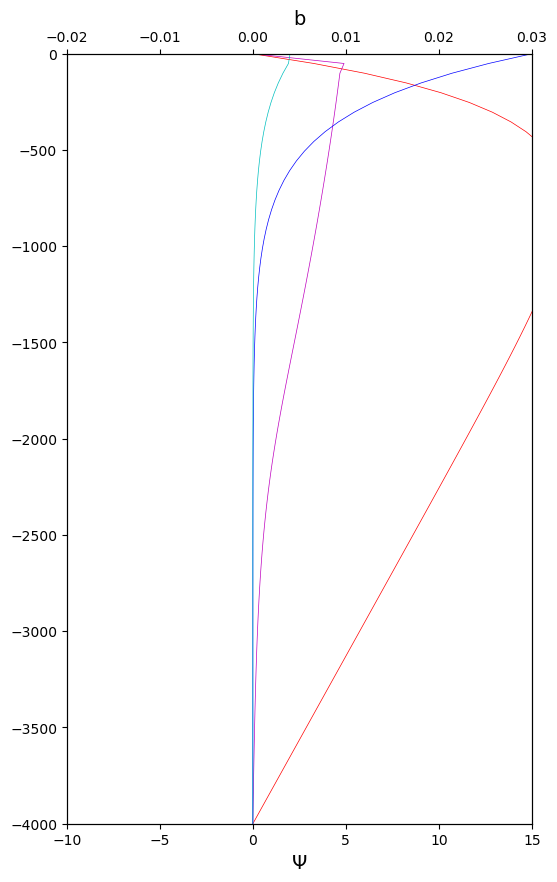

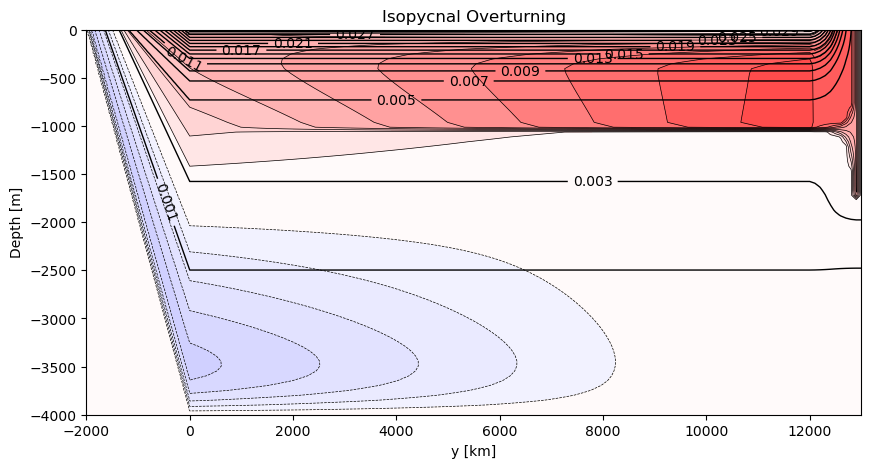

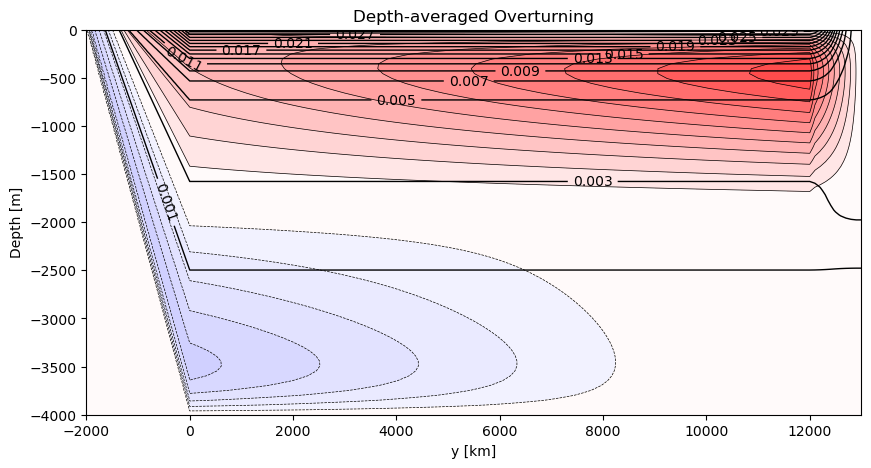

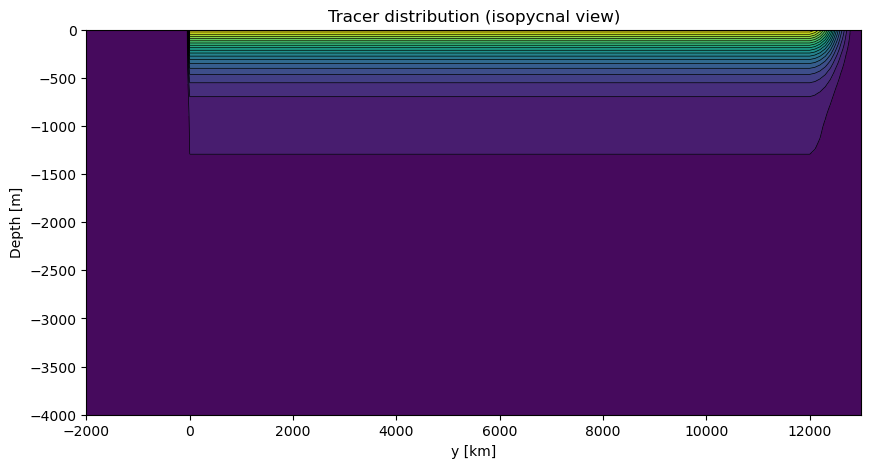

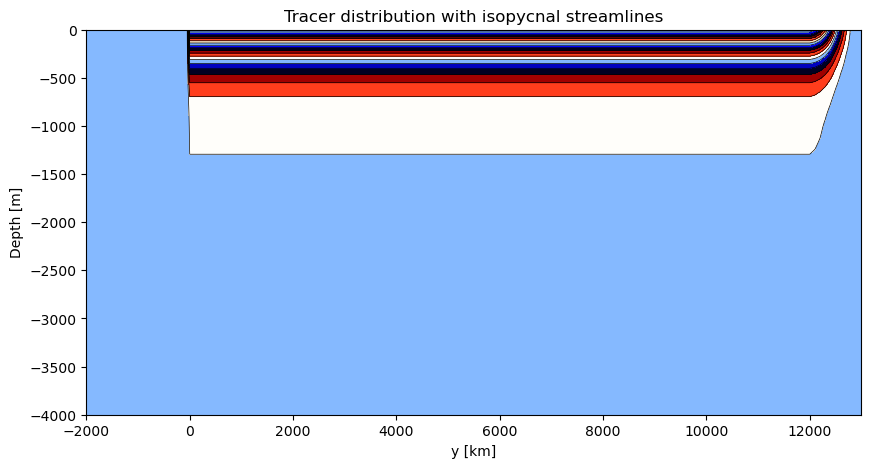

In [20]:
'''
This script shows an example of a "two column" model for the 
overturning circulation in a basin connected to a channel in the south.
The first column represents the basin, while the second column represents
the northern sinking region. The overtunning circulation is computed at
the northern end of the basin (at the interface to the northern sinking region)
and at the southern end of the basin (at the interface to the channel).
The parameters chosen here follow more or less the "control" experiment of Nikurashin
and Vallis (2012, JPO).
'''
from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

# boundary conditions:
bs = 0.03
bs_north = 0.004
bmin = 0.0

# S.O. surface boundary conditions and grid:
l = 2.e6
y = np.asarray(np.linspace(0, l, 40))
#Although the model can emulate the effect of a meridionally varying wind-stress,
# that feature is in "beta" and we are here for simplicity using a constant
# wind-stress (approximately the average over the channel in NV12):
tau = 0.13
# from what I can infer, NV12 use an approximately quadratic surface temperature
# profile in the channel for their SAMBUCA simulations:
bs_SO = (bs-bmin) * (y / y[-1])**2 + bmin

A_basin = 6e13    #area of the basin
A_north = A_basin / 50.    #area of northern sinking region

# time-stepping parameters:
dt = 86400 * 30    # time-step for vert. adv. diff. calc.
MOC_up_iters = int(
    np.floor(2. * 360 * 86400 / dt)
)    # multiplier for MOC time-step (MOC is updated every MOC_up_iters time steps)
plot_iters = int(
    np.ceil(300 * 360 * 86400 / dt)
)    # plotting frequency (in iterations)
total_iters = int(
    np.ceil(3500 * 360 * 86400 / dt)
)    # total number of timesteps

kappa = 2e-5

# create vertical grid:
z = np.asarray(np.linspace(-4000, 0, 80))


# Initial conditions for buoyancy profile in the basin
def b_basin(z):
  return bs * np.exp(z / 300.)
def b_north(z):
  return bs_north * np.exp(z / 300.)


# create N.A. overturning model instance
AMOC = Psi_Thermwind(z=z, b1=b_basin, b2=b_north, f=1e-4)
# and solve for initial overturning streamfunction:
AMOC.solve()
# evaluate overturning in isopycnal space:
[Psi_iso_b, Psi_iso_n] = AMOC.Psibz()

# create S.O. overturning model instance
SO = Psi_SO(
    z=z,
    y=y,
    b=b_basin(z),
    bs=bs_SO,
    tau=tau,
    f=1e-4,
    L=5e6,
    KGM=1000.,
    c=0.1,
    bvp_with_Ek=True
)
SO.solve()

# create adv-diff column model instance for basin
basin = Column(z=z, kappa=kappa, Area=A_basin, b=b_basin, bs=bs, bbot=bmin)
# create adv-diff column model instance for basin
north = Column(z=z, kappa=kappa, Area=A_north, b=b_north, bs=bs_north, bbot=bmin)


basin.tracer = np.zeros_like(z)
north.tracer = np.zeros_like(z)



# Create figure:
fig = plt.figure(figsize=(6, 10))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()
plt.ylim((-4e3, 0))
ax1.set_xlim((-10, 15))
ax2.set_xlim((-0.02, 0.03))
ax1.set_xlabel('$\Psi$', fontsize=14)
ax2.set_xlabel('b', fontsize=14)

# Main time-stepping loop:
for ii in range(0, total_iters):
  # update buoyancy profile
  # using z-coordinate overturning:
  #wAb=(AMOC.Psi-SO.Psi)*1e6
  #wAN=-AMOC.Psi*1e6
  # using isopycnal overturning:
  if ii % 3000 == 0:   # or every timestep
    basin.add_tracer(amount=1.0, depth_range=None, as_concentration=False)

  wAb = (Psi_iso_b - SO.Psi) * 1e6
  wAN = -Psi_iso_n * 1e6
  basin.timestep(wA=wAb, dt=dt)
  north.timestep(wA=wAN, dt=dt, do_conv=True)

  vdx_NtoB = wAN / north.Area(z)     # velocity (m s⁻¹)
  vdx_BtoN = -vdx_NtoB               # opposite direction
  basin.horadv_tracer(
    vdx_in=vdx_BtoN,
    tracer_in=north.tracer,
    dt=dt)
  north.horadv_tracer(
       vdx_in=vdx_NtoB,
       tracer_in=basin.tracer,
       dt=dt)

  if ii % MOC_up_iters == 0:
    # update overturning streamfunction (can be done less frequently)
    AMOC.update(b1=basin.b, b2=north.b)
    AMOC.update_tracer(t1 = basin.tracer, t2 = north.tracer)
    AMOC.solve()
    [Psi_iso_b, Psi_iso_n] = AMOC.Psibz()
    SO.update(b=basin.b)
    SO.update_tracer(tracer = basin.tracer)
    SO.solve()
  if ii % plot_iters == 0:
    # Plot current state:
    ax1.plot(AMOC.Psi, AMOC.z, linewidth=0.5, color='r')
    ax1.plot(SO.Psi, SO.z, linewidth=0.5, color='m')
    ax2.plot(basin.b, basin.z, linewidth=0.5, color='b')
    ax2.plot(north.b, north.z, linewidth=0.5, color='c')
    plt.pause(0.01)

# Plot final results over time-iteration plot:
ax1.plot(AMOC.Psi, AMOC.z, linewidth=2, color='r')
ax1.plot(SO.Psi, SO.z, linewidth=2, color='m')
ax1.plot(SO.Psi_Ek, SO.z, linewidth=1, color='m', linestyle='--')
ax1.plot(SO.Psi_GM, SO.z, linewidth=1, color='m', linestyle=':')
ax2.plot(basin.b, basin.z, linewidth=2, color='b')
ax2.plot(north.b, basin.z, linewidth=2, color='c')
ax1.plot(0. * AMOC.z, AMOC.z, linewidth=0.5, color='k')

#==============================================================================
# Everything below is just to make fancy 2D plots:
# This is mostly an exercise in interpolation, but useful to visualize solutions

# first interpolate buoyancy in channel along constant-slope isopycnals:
bint = Interpolate_channel(y=y, z=z, bs=bs_SO, bn=basin.b)
bsouth = bint.gridit()
# buoyancy in the basin is all the same:
ybasin = np.linspace(200., 12000., 60)
bbasin = np.tile(basin.b, (len(ybasin), 1))
# finally, interpolate buoyancy in the north:
ynorth = np.linspace(12100., 13000., 10)
bnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
  bnorth[:, iz] = interp1d([11900., 12000., 12900., 13000.], [
      basin.b[iz], basin.b[iz], north.b[iz], north.b[iz]
  ],
                           kind='quadratic')(ynorth)
# now stick it all together:
ynew = np.concatenate(((y-l) / 1e3, ybasin, ynorth))
bnew = np.concatenate((bsouth, bbasin, bnorth))

# Evaluate isopycnal overturning streamfunction at all latitudes:
psiarray_iso = np.zeros((len(ynew), len(z)))
psiarray_z = np.zeros((len(ynew), len(z)))
for iy in range(1, len(y)):
  # in the channel, interpolate SO.Psi onto local isopycnal depth:
  psiarray_iso[iy, :] = np.interp(bnew[iy, :], basin.b, SO.Psi)
  psiarray_z[iy, :] = psiarray_iso[iy, :]
for iy in range(len(y), len(y) + len(ybasin)):
  # in the basin, linearly interpolate between Psi_SO and Psi_AMOC:
  psiarray_iso[iy, :] = (
      ynew[iy] * AMOC.Psibz()[0] + (10000. - ynew[iy]) * SO.Psi
  ) / 10000.
  psiarray_z[iy, :
             ] = (ynew[iy] * AMOC.Psi + (10000. - ynew[iy]) * SO.Psi) / 10000.
for iy in range(len(y) + len(ybasin), len(ynew)):
  # in the north, interpolate AMOC.psib to local isopycnal depth:
  psiarray_iso[iy, :] = np.interp(bnew[iy, :], AMOC.bgrid, AMOC.Psib())
  psiarray_z[iy, :] = ((13000. - ynew[iy]) * AMOC.Psi) / 1000.
psiarray_iso[-1, :] = 0.

blevs = np.arange(0.001, 0.03, 0.002)
# Notice that the contour level for Psi is 0.5 SV for negative values
# and 1 SV for positive values. This appers to be what was used in NV2012.
plevs = np.concatenate((np.arange(-15., -0.4, 0.5), np.arange(1., 16., 1.)))

# plot isopycnal overturning:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
CS = ax1.contour(
    ynew,
    z,
    bnew.transpose(),
    levels=blevs,
    colors='k',
    linewidths=1.0,
    linestyles='solid'
)
ax1.clabel(CS, fontsize=10)
ax1.contour(
    ynew,
    z,
    psiarray_iso.transpose(),
    levels=plevs,
    colors='k',
    linewidths=0.5
)
CS = ax1.contourf(
    ynew,
    z,
    psiarray_iso.transpose(),
    levels=plevs,
    cmap=plt.cm.bwr,
    vmin=-15,
    vmax=15
)
#fig.colorbar(CS, ticks=plevs[0::2], orientation='vertical')
ax1.set_xlabel('y [km]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('Isopycnal Overturning')

# plot z-coord. overturning:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
CS = ax1.contour(
    ynew,
    z,
    bnew.transpose(),
    levels=blevs,
    colors='k',
    linewidths=1.0,
    linestyles='solid'
)
ax1.clabel(CS, fontsize=10)
ax1.contour(
    ynew, z, psiarray_z.transpose(), levels=plevs, colors='k', linewidths=0.5
)
CS = ax1.contourf(
    ynew,
    z,
    psiarray_z.transpose(),
    levels=plevs,
    cmap=plt.cm.bwr,
    vmin=-15,
    vmax=15
)
#fig.colorbar(CS, ticks=plevs[0::2], orientation='vertical')
ax1.set_xlabel('y [km]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('Depth-averaged Overturning')

# =============================================================================
# Fancy 2D plots for tracer (analogous to the buoyancy section)
# =============================================================================

# --- 2D plotting for tracer ---

# 1. Interpolate tracer along the Southern Ocean channel
tint = Interpolate_channel(y=y, z=z, bs=np.zeros(np.shape(bs_SO)), bn=basin.tracer)  # SO tracer starts at 0
t_south = tint.gridit()  # shape (len(y), len(z))

# 2. Tracer in the basin (assume uniform in y)
ybasin = np.linspace(200., 12000., 60)
t_basin = np.tile(basin.tracer, (len(ybasin), 1))  # shape (len(ybasin), len(z))

# 3. Tracer in the northern column
ynorth = np.linspace(12100., 13000., 10)
t_north = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
    t_north[:, iz] = interp1d([11900., 12000., 12900., 13000.],
                               [basin.tracer[iz], basin.tracer[iz], north.tracer[iz], north.tracer[iz]],
                               kind='quadratic')(ynorth)

# 4. Concatenate the full domain
yfull = np.concatenate(((y-l)/1e3, ybasin, ynorth))
tfull = np.concatenate((t_south, t_basin, t_north))  # shape (len(yfull), len(z))

# 5. Plot tracer in isopycnal space
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)

# contour levels for tracer (adjust as needed)
t_levels = np.linspace(np.min(tfull), np.max(tfull), 20)

CS = ax.contour(yfull, z, tfull.T, levels=t_levels, colors='k', linewidths=0.5)
ax.contourf(yfull, z, tfull.T, levels=t_levels, cmap=plt.cm.viridis)
ax.set_xlabel('y [km]')
ax.set_ylabel('Depth [m]')
ax.set_title('Tracer distribution (isopycnal view)')
plt.show()

# 6. If desired, overlay streamlines of the overturning
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
CS = ax.contour(yfull, z, tfull.T, levels=t_levels, colors='k', linewidths=0.5)
ax.contourf(yfull, z, tfull.T, levels=t_levels, cmap=plt.cm.flag)
# ax.contour(ynew, z, psiarray_iso.T, levels=plevs, colors='white', linewidths=0.5)  # psiarray_iso from your existing code
ax.set_xlabel('y [km]')
ax.set_ylabel('Depth [m]')
ax.set_title('Tracer distribution with isopycnal streamlines')
plt.show()



In [12]:
np.shape(b_basin(z))

(80,)

(80,)